# 04b - Pose Visualization
Overlay predicted keypoints on raw videos to generate labeled MP4 videos.

In [1]:
# ===== CONFIGURATION =====
# GitHub -- do not change
GITHUB_REPO_URL = "https://github.com/kaarthik-balakrishnan/LightningPoseTrack.git"
GIT_BRANCH = "main"

# Google Drive root -- change this to match your Drive structure
DRIVE_ROOT = "/content/drive/Shareddrives/3R.Data/1P.SPRIND.Data/POC/Behavior"

OUTPUT_ROOT = "/content/drive/MyDrive/LightningPoseTrack"

# Derived paths (change if your folders are at custom locations)

DRIVE_RAW_VIDEOS = f"{DRIVE_ROOT}/260608.00000009"               # Input: session video folders
DRIVE_POSE_OUTPUTS = f"{OUTPUT_ROOT}/260608.00000009/pose_outputs"     # Output: pose prediction CSVs
DRIVE_LABELED_VIDEOS = f"{OUTPUT_ROOT}/260608.00000009/pose_outputs/labeled_videos"  # Output

CONFIDENCE_THRESHOLD = 0.5     # Skip keypoints below this confidence
KEYPOINT_RADIUS = 4            # Circle radius in pixels
LINE_THICKNESS = 2

# Google Drive folder ID (for reference)
DRIVE_FOLDER_ID = "1X_41ZW3HfwVeft2lPld3XNqXsdxRDIwb"

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os, sys
REPO_DIR = "/content/LightningPoseTrack"
if not os.path.exists(REPO_DIR):
    !git clone {GITHUB_REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git pull
%cd {REPO_DIR}
sys.path.insert(0, REPO_DIR)

Cloning into '/content/LightningPoseTrack'...
remote: Enumerating objects: 1374, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 1374 (delta 88), reused 63 (delta 27), pack-reused 1237 (from 1)
Receiving objects: 100% (1374/1374), 343.65 MiB | 24.15 MiB/s, done.
Resolving deltas: 100% (262/262), done.
/content/LightningPoseTrack


In [4]:
!pip install --quiet opencv-python pandas numpy pyarrow

In [6]:
# ===== CHAMBER BOUNDARY =====
# Define polygon region (list of [x, y] vertices) where pigs are tracked.
# Run the "Find Chamber Corners" cell below — hover over the image to see
# pixel coordinates at the cursor, then enter the 4 corners below.
# First and last vertex MUST be the same (closed polygon).
#
CAMERA_BOUNDARIES = {
    1: [[153, 388], [1415, 388], [1415, 907], [153, 907]],  # <-- REPLACE ME
    2: [[252, 464], [1754, 432], [1761, 640], [249, 640]],  # <-- REPLACE ME
    3: [[166, 421], [1537, 453], [1535, 610], [160, 608]],  # <-- REPLACE ME
    4: [[360, 360], [1348, 384], [1368, 840], [367, 835]],  # <-- REPLACE ME
}


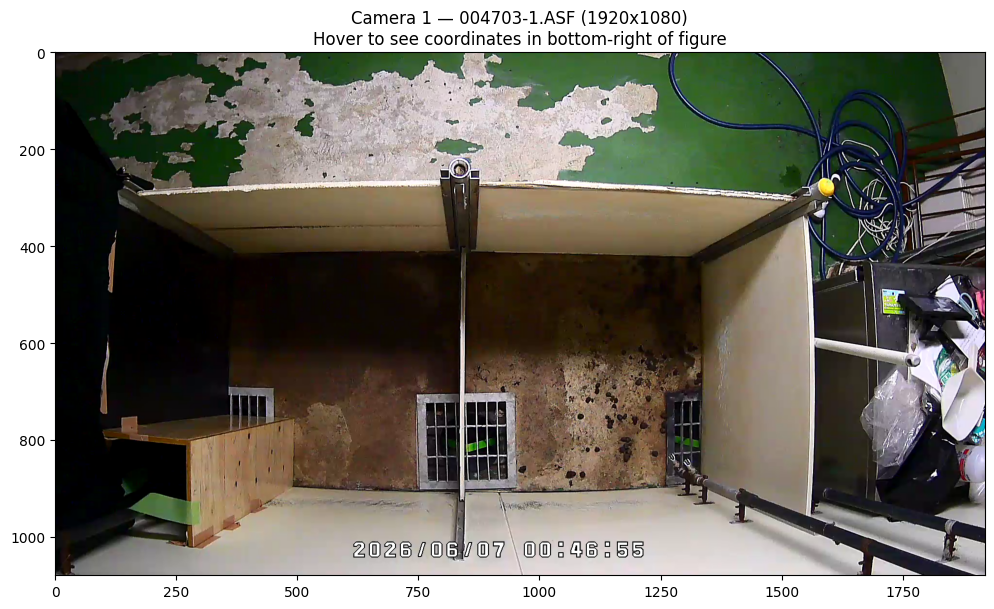

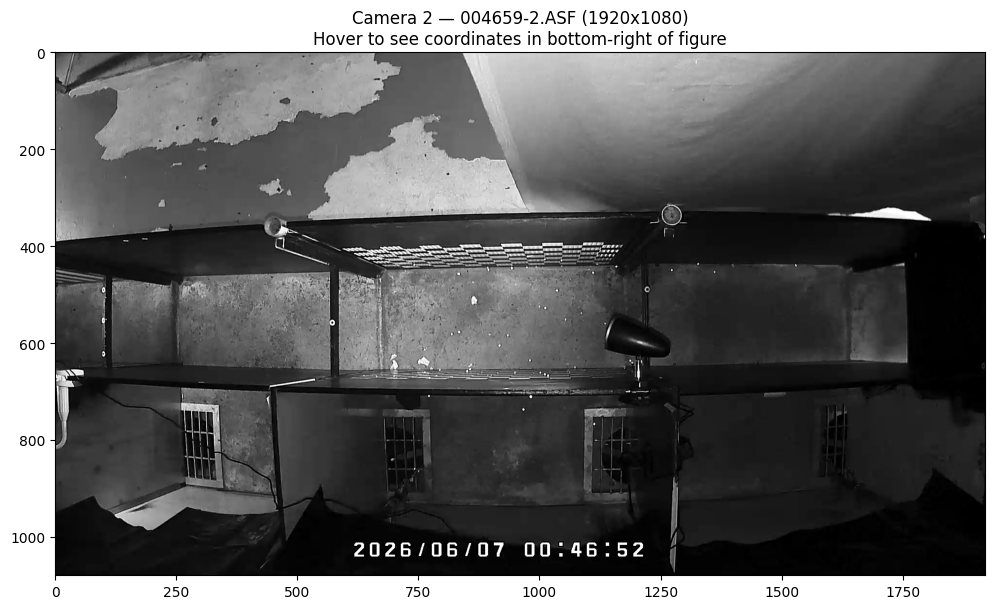

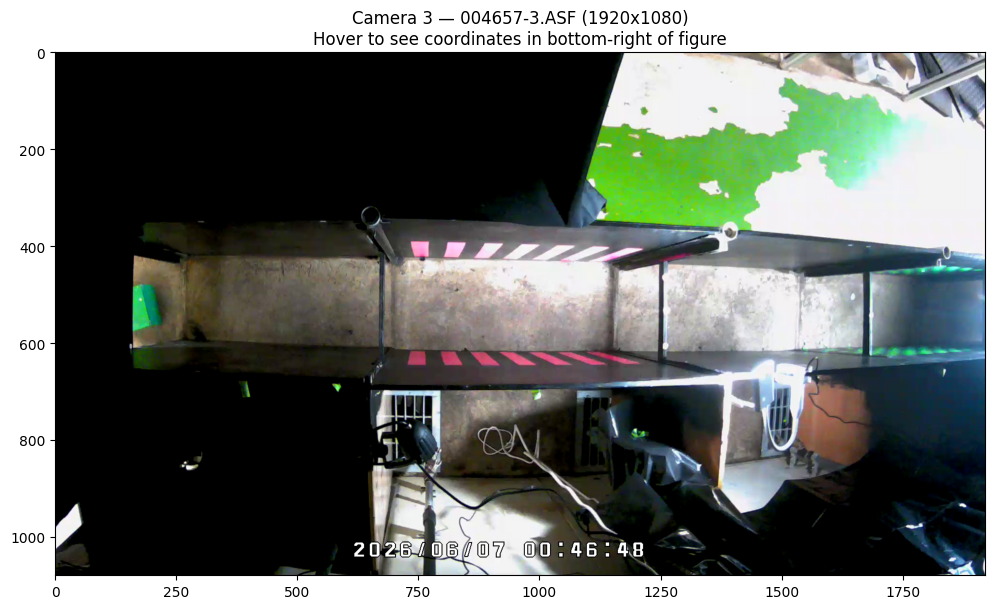

KeyboardInterrupt: 

In [5]:
# ===== FIND CHAMBER CORNERS (run once) =====
# Displays one frame from each camera. Hover over the image — matplotlib
# shows the pixel coordinates (x, y) at the bottom-right of the figure.
# Note the 4 chamber corners for each camera, then enter them above.

import cv2
import matplotlib.pyplot as plt
from pathlib import Path

from src.io.video_inventory import scan_videos

df = scan_videos(DRIVE_RAW_VIDEOS, verbose=False)

for cam in [1, 2, 3, 4]:
    row = df[df["camera"] == cam].iloc[0]
    video_path = Path(DRIVE_RAW_VIDEOS) / row["path"]
    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        print(f"  Camera {cam}: could not read first frame")
        continue
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    h, w = frame_rgb.shape[:2]
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(frame_rgb)
    ax.set_title(f"Camera {cam} — {row['filename']} ({w}x{h})\nHover to see coordinates in bottom-right of figure")
    plt.show()


In [7]:
from src.io.video_inventory import scan_videos

df = scan_videos(DRIVE_RAW_VIDEOS)
print(f"Found {len(df)} videos to visualize")
df[["filename", "session", "camera", "frame_count", "duration_min"]]

  Root path: /content/drive/Shareddrives/3R.Data/1P.SPRIND.Data/POC/Behavior/260608.00000009
  Path exists: True
  First 20 entries: ['004653-4.ASF', '004657-3.ASF', '004659-2.ASF', '004703-1.ASF', '004757-3.ASF', '004756-2.ASF', '004818-4.ASF', '014853-4.ASF', '015213-1.ASF', '015206-2.ASF', '015201-3.ASF', '015156-4.ASF', '015543-4.ASF', '035426-4.ASF', '035429-3.ASF', '035430-2.ASF', '035433-1.ASF', '035603-2.ASF', '035605-3.ASF', '035612-4.ASF']
  004653-4.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  004657-3.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  004659-2.ASF — OK (h264, 1920x1080, 10.2 fps, 616f)
  004703-1.ASF — OK (h264, 1920x1080, 10.2 fps, 1119f)
  004756-2.ASF — OK (h264, 1920x1080, 10.2 fps, 616f)
  004757-3.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  004818-4.ASF — OK (h264, 1920x1080, 10.0 fps, 1861f)
  014853-4.ASF — OK (h264, 1920x1080, 10.0 fps, 601f)
  015156-4.ASF — OK (h264, 1920x1080, 10.0 fps, 1291f)
  015201-3.ASF — OK (h264, 1920x1080, 10.0 fps, 1021f)
  

,filename,session,camera,frame_count,duration_min
0,004653-4.ASF,260608.00000009,4,601,1.00
1,004657-3.ASF,260608.00000009,3,601,1.00
2,004659-2.ASF,260608.00000009,2,616,1.00
3,004703-1.ASF,260608.00000009,1,1119,1.82
4,004756-2.ASF,260608.00000009,2,616,1.00
...,...,...,...,...,...
122,090307-2.ASF,260608.00000009,2,1129,1.84
123,090314-1.ASF,260608.00000009,1,924,1.50
124,090409-4.ASF,260608.00000009,4,1396,4.65
125,090715-3.ASF,260608.00000009,3,1031,1.72


In [9]:
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from src.features.boundary import filter_keypoints_by_boundary

KEYPOINT_NAMES = [
    "snout", "left_ear", "right_ear", "neck",
    "shoulders", "mid_back", "hip", "tail_base",
]

# Skeleton edges (index pairs into KEYPOINT_NAMES)
SKELETON = [
    (0, 1),  # snout -> left_ear
    (0, 2),  # snout -> right_ear
    (1, 3),  # left_ear -> neck
    (2, 3),  # right_ear -> neck
    (3, 4),  # neck -> shoulders
    (4, 5),  # shoulders -> mid_back
    (5, 6),  # mid_back -> hip
    (6, 7),  # hip -> tail_base
]

# Distinct BGR colors, one per keypoint
COLORS = [
    (0, 255, 0),    # snout - green
    (255, 0, 0),    # left_ear - blue
    (0, 0, 255),    # right_ear - red
    (255, 255, 0),  # neck - cyan
    (255, 0, 255),  # shoulders - magenta
    (0, 255, 255),  # mid_back - yellow
    (128, 128, 255),# hip - pink
    (255, 128, 128),# tail_base - light blue
]

out_root = Path(DRIVE_LABELED_VIDEOS)
out_root.mkdir(parents=True, exist_ok=True)

for _, row in tqdm(df.iterrows(), total=len(df), desc="Rendering labeled videos"):
    video_path = Path(DRIVE_RAW_VIDEOS) / row["path"]
    session = row["session"]
    camera = row["camera"]
    stem = Path(row["filename"]).stem
    fps = row["fps"]
    width = int(row["width"])
    height = int(row["height"])

    # Corresponding pose parquet
    pose_file = Path(DRIVE_POSE_OUTPUTS)  / f"{stem}_cam{camera}_pose.parquet"
    if not pose_file.exists():
        print(f"  Skipping {stem} — no pose file at {pose_file}")
        continue

    out_file = out_root / f"{stem}_cam{camera}_labeled.mp4"
    if out_file.exists():
        print(f"  Skipping {out_file.name} (already exists)")
        continue

    # Load predicted keypoints
    pose_df = pd.read_parquet(str(pose_file))


    # Apply chamber boundary filter to remove wayward predictions
    poly = CAMERA_BOUNDARIES.get(camera)
    if poly is not None and len(poly) > 2:
        pose_df = filter_keypoints_by_boundary(pose_df, poly, KEYPOINT_NAMES)

    frame_idx = 0
    # Debug: print first frame values for the first video
    if frame_idx == 0:
        first = pose_df.iloc[0]
        print(f"  Debug {stem} — first frame keypoints:")
        for kp in KEYPOINT_NAMES:
            print(f"    {kp}: x={first[f'{kp}_x']:.2f}, y={first[f'{kp}_y']:.2f}, conf={first[f'{kp}_likelihood']:.3f}")
    # Open source video
    cap = cv2.VideoCapture(str(video_path))

    # Write to local temp first, then copy to Drive (avoids silent codec/Drive-sync failures)
    tmp_file = Path(f"/content/tmp_labeled/{session}_{stem}_cam{camera}_labeled.mp4")
    tmp_file.parent.mkdir(parents=True, exist_ok=True)

    # Try codecs in order — mp4v is most portable on Colab
    codecs = ["mp4v", "avc1", "X264"]
    writer = None
    for codec in codecs:
        fourcc = cv2.VideoWriter_fourcc(*codec)
        writer = cv2.VideoWriter(str(tmp_file), fourcc, fps, (width, height))
        if writer.isOpened():
            break
        writer.release()
        writer = None

    if writer is None:
        print(f"  FAILED {stem} — no working codec among {codecs}")
        cap.release()
        continue

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx < len(pose_df):
            row_data = pose_df.iloc[frame_idx]
            # Collect visible keypoints for this frame
            pts = {}
            for i, kp in enumerate(KEYPOINT_NAMES):
                cx = row_data[f"{kp}_x"]
                cy = row_data[f"{kp}_y"]
                conf = row_data[f"{kp}_likelihood"]
                if conf >= CONFIDENCE_THRESHOLD and (int(round(cx)) != 0 or int(round(cy)) != 0):
                    pts[i] = (int(round(cx)), int(round(cy)))

            # Draw skeleton edges
            for i, j in SKELETON:
                if i in pts and j in pts:
                    cv2.line(frame, pts[i], pts[j], COLORS[i], LINE_THICKNESS)

            # Draw keypoint circles
            for i, pt in pts.items():
                cv2.circle(frame, pt, KEYPOINT_RADIUS, COLORS[i], -1)
                cv2.circle(frame, pt, KEYPOINT_RADIUS, (255, 255, 255), 1)

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()

    # Verify temp file is valid before copying to Drive
    if not tmp_file.exists() or tmp_file.stat().st_size == 0:
        print(f"  FAILED {stem} — temp file is empty/missing")
        continue

    out_file.parent.mkdir(parents=True, exist_ok=True)
    import shutil
    shutil.copy2(str(tmp_file), str(out_file))
    tmp_file.unlink()
    print(f"  Saved: {out_file} ({frame_idx} frames, {out_file.stat().st_size / 1e6:.1f} MB)")

print("\nAll labeled videos generated!")

Rendering labeled videos:   0%|          | 0/127 [00:00<?, ?it/s]

  Debug 004653-4 — first frame keypoints:
    snout: x=578.07, y=676.55, conf=0.928
    left_ear: x=521.97, y=685.70, conf=0.755
    right_ear: x=598.09, y=694.34, conf=0.962
    neck: x=591.94, y=704.91, conf=0.864
    shoulders: x=615.77, y=751.90, conf=0.908
    mid_back: x=599.29, y=797.13, conf=0.993
    hip: x=548.94, y=810.79, conf=0.895
    tail_base: x=507.08, y=815.01, conf=0.949
  Saved: /content/drive/MyDrive/LightningPoseTrack/260608.00000009/pose_outputs/labeled_videos/004653-4_cam4_labeled.mp4 (602 frames, 15.0 MB)
  Debug 004657-3 — first frame keypoints:
    snout: x=0.00, y=0.00, conf=0.000
    left_ear: x=0.00, y=0.00, conf=0.000
    right_ear: x=0.00, y=0.00, conf=0.000
    neck: x=0.00, y=0.00, conf=0.000
    shoulders: x=0.00, y=0.00, conf=0.000
    mid_back: x=0.00, y=0.00, conf=0.000
    hip: x=0.00, y=0.00, conf=0.000
    tail_base: x=0.00, y=0.00, conf=0.000
  Saved: /content/drive/MyDrive/LightningPoseTrack/260608.00000009/pose_outputs/labeled_videos/004657-3

In [ ]:
# Verify outputs
out_root = Path(DRIVE_LABELED_VIDEOS)
output_files = list(out_root.rglob("*.mp4"))
print(f"Total labeled videos: {len(output_files)}")
for f in output_files:
    print(f"  {f.relative_to(out_root)}")